____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import find_combination, create_DS



import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

c0 ={'acc':'#941717', 'coriolis':'#388E3C','ggrad':'#42A5F5', 'wind':'#FFA000'}

/Users/mdemol/code/pynsitu/pynsitu/__init__.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour = Timedelta("1H")


_______
# Data

In [2]:
dfc = pd.read_csv(os.path.join(zarr_dir, 'coloc_nearest.csv')).set_index('row_number')
id_comb = find_combination(dfc)
DS = create_DS(dfc, id_comb)
DSS = DS.where(DS.drifter_type.isin(surface_drifters), drop=True)
DSD = DS.where(DS.drifter_type.isin(depth_drifters), drop=True)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/core/dataset.py:4789: UserWarning: No index created for dimension id_comb because variable id_comb is not a coordinate. To create an index for id_comb, please first call `.set_coords('id_comb')` on this object.
  warnings.warn(


# Visualization

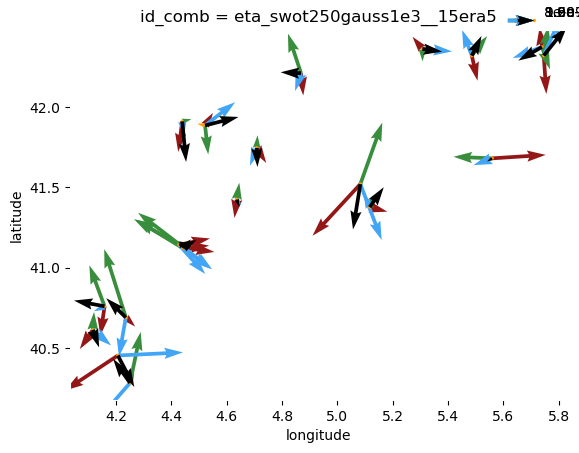

In [17]:
ds__= DS.sel(id_comb = 'eta_swot250gauss1e3__15era5').isel(row_number=slice(20,40))
fig, ax = plt.subplots()
s = 3e-4
ds__.plot.quiver('longitude', 'latitude', 'acce', 'accn', color =c0['acc'], pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'coriolise', 'coriolisn', color =c0['coriolis'],pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'ggrade', 'ggradn', color =c0['ggrad'],pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'winde', 'windn', color =c0['wind'],pivot='tail', scale=s)
ds__.plot.quiver('longitude', 'latitude', 'sume', 'sumn', color ='k', pivot='tail', scale=s )

In [18]:
def compute_mean_square(ds):
    dss = (ds**2).mean(dim='row_number')
    dss['Se'] = dss.acce + dss.coriolise + dss.ggrade + dss.winde
    dss['Sn'] = dss.accn + dss.coriolisn + dss.ggradn + dss.windn
    #true and err
    for direction in ['e', 'n']:
        for v in ['acc', 'coriolis', 'ggrad', 'wind'] : 
                dss['true'+direction+'_'+v] = (dss[v+direction] - dss['sum'+direction] + dss['exc'+direction+'_'+v])/2
                dss['err'+direction+'_'+v] = (dss[v+direction]  + dss['sum'+direction] - dss['exc'+direction+'_'+v])/2
    #pairs contributions
    for v in [v for v in dss if 'prod' in v]:
        dss[v]=-2*ds[v].mean(dim='row_number')
    return dss
dsm = compute_mean_square(DS)
dsms =compute_mean_square(DSS)
dsmd =compute_mean_square(DSD)

In [19]:
dsmd.sume/dsmd.Se, dsmd.sumn/dsmd.Sn

(<xarray.DataArray (id_comb: 16)> Size: 128B
 array([0.43202179, 0.41557424, 0.44899871, 0.44202145, 0.46628682,
        0.46595546, 0.4222764 , 0.40032549, 0.38863013, 0.37204546,
        0.4464644 , 0.43992962, 0.46719242, 0.46745167, 0.37410574,
        0.35167203])
 Coordinates:
   * id_comb  (id_comb) <U63 4kB 'duacs_ssha_karin_2_filtered_swot250naive__0e...,
 <xarray.DataArray (id_comb: 16)> Size: 128B
 array([0.43818017, 0.43556979, 0.42299518, 0.41653258, 0.50177068,
        0.49948885, 0.39297643, 0.38807974, 0.40427813, 0.40210269,
        0.42142482, 0.41472301, 0.49990869, 0.497681  , 0.35798418,
        0.35326758])
 Coordinates:
   * id_comb  (id_comb) <U63 4kB 'duacs_ssha_karin_2_filtered_swot250naive__0e...)

In [20]:
dsmd.sume/dsmd.Se

<xarray.DataArray (id_comb: 16)> Size: 128B
array([0.43202179, 0.41557424, 0.44899871, 0.44202145, 0.46628682,
       0.46595546, 0.4222764 , 0.40032549, 0.38863013, 0.37204546,
       0.4464644 , 0.43992962, 0.46719242, 0.46745167, 0.37410574,
       0.35167203])
Coordinates:
  * id_comb  (id_comb) <U63 4kB 'duacs_ssha_karin_2_filtered_swot250naive__0e...

In [21]:
dsms.sume/dsms.Se

<xarray.DataArray (id_comb: 16)> Size: 128B
array([0.34874472, 0.39120917, 0.34718535, 0.42463634, 0.34437326,
       0.42541429, 0.3414663 , 0.38160016, 0.31651239, 0.36177136,
       0.3476061 , 0.42531808, 0.34452733, 0.4255845 , 0.3080806 ,
       0.35107416])
Coordinates:
  * id_comb  (id_comb) <U63 4kB 'duacs_ssha_karin_2_filtered_swot250naive__0e...

In [22]:
# Best comb
bs =dsms.sel(id_comb = 'eta_swot250gauss1e3__0era5')
bd =dsmd.sel(id_comb = 'eta_swot250gauss1e3__15era5')
bsn =dsms.sel(id_comb = 'eta_swot250naive__0era5')
bdn =dsmd.sel(id_comb = 'eta_swot250naive__15era5')

In [23]:
bs

<xarray.Dataset> Size: 636B
Dimensions:               ()
Coordinates:
    id_comb               <U63 252B 'eta_swot250gauss1e3__0era5'
Data variables: (12/48)
    sume                  float64 8B 2.665e-10
    acce                  float64 8B 1.911e-10
    exce_acc              float64 8B 3.575e-10
    coriolise             float64 8B 3.959e-10
    exce_coriolis         float64 8B 5.178e-10
    ggrade                float64 8B 2.557e-10
    ...                    ...
    truen_coriolis        float64 8B 3.007e-10
    errn_coriolis         float64 8B 8.95e-11
    truen_ggrad           float64 8B 1.511e-10
    errn_ggrad            float64 8B 1.396e-10
    truen_wind            float64 8B 1.063e-11
    errn_wind             float64 8B -6.357e-12

In [24]:
def synthetic_figure(ds, direction, ax, xlim=None) :
    plt.rcParams["axes.edgecolor"] = "w"
    a=1.5
    bbox = dict(facecolor='w', alpha=0.8, edgecolor='w')
    def prod(key1, key2) :
        return 'prod'+direction+'_'+key1+'_'+key2
        
    ts = float(ds['S'+direction])
    print(ts)
    #gap between bars for readability
    if xlim : b=xlim/400
    else : b=ts/400
    
    ## INDIVIDUAL MS ##
    ax.barh(2*a, ds['acc'+direction], color= c0['acc'], label = 'Inertial acceleration')
    ax.barh(2*a, ds['coriolis'+direction], left =ds['acc'+direction]+b , color= c0['coriolis'], label = 'Coriolis acceleration')
    ax.barh(2*a, ds['ggrad'+direction], left =ds['acc'+direction]+ds['coriolis'+direction]+2*b , color= c0['ggrad'], label = 'Pressure gradient term')
    ax.barh(2*a, ds['wind'+direction], left =ds['acc'+direction]+ds['coriolis'+direction]+ds['ggrad'+direction]+3*b, color= c0['wind'], label = 'Wind term')
    

    ax.text(ts/2, 2*a+0.5, r'Individual MS $A_i$', ha='center') 
    #percentage + MS
    key = ['acc', 'coriolis', 'ggrad', 'wind']
    for i in range(len(key)) :
        ax.text(sum([ds[v+direction] for v in key[:i]])+ds[key[i]+direction]/2+i*b, 2*a, f'{int(np.rint((ds[key[i]+direction]/ts).values*100))} %', ha='center',bbox=bbox )
        ax.text(sum([ds[v+direction] for v in key[:i]])+ds[key[i]+direction]/2+i*b, 2*a-0.55, f'{np.format_float_scientific(ds[key[i]+direction].values,precision = 1)}', ha='center')
    
    #accolade
    c = 1e-12
    id1 =0
    id2 = ts + 3*b
    bx = [id1, id1, id2, id2]
    by = [3.70, 3.75, 3.75, 3.70]
    ax.plot(bx, by, 'k-', lw=2)
    ax.text(ts, 3.8, r'$\Sigma$', fontsize=15, ha='center')
    
    ## CAPTURED PHYSICAL + ERRORS PARTS ##
    ax.barh(1*a, ds['true'+direction+'_acc'], color= c0['acc'])
    ax.barh(1*a, ds['err'+direction+'_acc'], left = ds['true'+direction+'_acc'], color= 'lightgrey', label='Errors')
    ax.barh(1*a, ds['true'+direction+'_coriolis'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+b, color= c0['coriolis'])
    ax.barh(1*a, ds['err'+direction+'_coriolis'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis'], color= 'lightgrey')
    ax.barh(1*a, ds['true'+direction+'_ggrad'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+b, color= c0['ggrad'])
    if ds['err'+direction+'_ggrad']>0 : 
        ax.barh(1*a, ds['err'+direction+'_ggrad'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+ds['true'+direction+'_ggrad'], color= 'lightgrey')
        ax.barh(1*a, ds['true'+direction+'_wind'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+ds['true'+direction+'_ggrad']+ds['err'+direction+'_ggrad']+b, color= c0['wind'])
        ax.barh(1*a, ds['err'+direction+'_wind'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+ds['true'+direction+'_ggrad']+ds['err'+direction+'_ggrad']+ds['true'+direction+'_wind'], color= 'lightgrey')
    else : 
        print('ok')
        ax.barh(1*a, ds['true'+direction+'_wind'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+ds['true'+direction+'_ggrad']+2*b, color= c0['wind'])
        ax.barh(1*a, ds['err'+direction+'_wind'], left =ds['true'+direction+'_acc']+ds['err'+direction+'_acc']+ ds['true'+direction+'_coriolis']+ ds['err'+direction+'_coriolis']+ds['true'+direction+'_ggrad']+ds['true'+direction+'_wind']+2*b, color= 'lightgrey')
    
    ax.text(ts/2, 1*a+0.5, r'Balanced physical and errors parts MS $B_i$ and $E_i$', ha='center') 
    #percentage + MS
    key = ['true'+direction+'_acc','err'+direction+'_acc', 'true'+direction+'_coriolis','err'+direction+'_coriolis', 'true'+direction+'_ggrad','err'+direction+'_ggrad', 'true'+direction+'_wind', 'err'+direction+'_wind']
    for i in range(len(key)) :
        d=0
        dx=0
        if i==len(key)-1 : 
            d=-0.1*a 
            dx = 3e-11
        if i==len(key)-2 : d=0.1*a 
        #if 'aviso' in dic['ggrad'] and i==len(key)-3 : d=-0.1*a
        ax.text(sum([ds[v] for v in key[:i]])+ds[key[i]]/2+i*b/2, a+d, f'{int(np.rint((ds[key[i]]/ts).values*100))} %', ha='center', bbox=bbox)
        d=0        
        if i%2 ==1 : d=-0.1*a
        ax.text(sum([ds[v] for v in key[:i]])+ds[key[i]]/2+i*b/2+dx, a+d -0.55, f'{np.format_float_scientific(ds[key[i]].values,precision = 1)}', ha='center')
        
    ## PAIRS + RESIDUAL ##
    plt.rcParams['hatch.linewidth'] = 10
    plt.rcParams['hatch.color'] = c0['ggrad']
    ax.barh(0, ds[prod('coriolis', 'ggrad')], color=c0['coriolis'], hatch='/')
    plt.rcParams['hatch.color'] = c0['coriolis']
    ax.barh(0, ds[prod('acc', 'coriolis')], color=c0['acc'], hatch='/', left = ds[prod('coriolis', 'ggrad')]+b)
    plt.rcParams['hatch.color'] = c0['acc']
    ax.barh(0, ds[prod('acc', 'ggrad')], color=c0['ggrad'], hatch='/', left = ds[prod('coriolis', 'ggrad')]+ds[prod('acc', 'coriolis')]+2*b)
    plt.rcParams['hatch.color'] = c0['wind']
    ax.barh(0, ds[prod('coriolis', 'wind')], color=c0['coriolis'], hatch='/', left = ds[prod('coriolis', 'ggrad')]+ds[prod('acc', 'coriolis')]+ds[prod('acc', 'ggrad')]+3*b)
    ax.barh(0, ds['sum'+direction], color='lightgrey', left = ds[prod('coriolis', 'ggrad')]+ds[prod('acc', 'coriolis')]+ds[prod('acc', 'ggrad')]+ds[prod('coriolis', 'wind')]+4*b)

    tts = ds[prod('coriolis', 'ggrad')]+ds[prod('acc', 'coriolis')]+ds[prod('acc', 'ggrad')]+ds[prod('coriolis', 'wind')]+4*b+ds['sum'+direction]
    print(tts)
    sum_pairs = ds[prod('coriolis', 'ggrad')]+ds[prod('acc', 'coriolis')]+ds[prod('acc', 'ggrad')]+ds[prod('coriolis', 'wind')]+3*b
    ax.text(sum_pairs/2, 0.6, r"Pairs' contributions $X_{ij}$", ha='center')
    
    #accolade
    c = 1e-12
    id1 =0
    id2 = sum_pairs
    bx = [id1, id1, id2, id2]
    by = [0.45, 0.5, 0.5, 0.45]
    ax.plot(bx, by, 'k-', lw=2)
    ax.text(sum_pairs + ds['sum'+direction]/2, 0.5, r'$S$', ha='center')

    #percentage + MS
    key = [prod('coriolis', 'ggrad'),prod('acc', 'coriolis'), prod('acc', 'ggrad'), prod('coriolis', 'wind')]
    for i in range(len(key)) :
        ax.text(sum([ds[v] for v in key[:i]])+ds[key[i]]/2+i*b, 0, f'{int(np.rint((ds[key[i]]/ts).values*100))} %', ha='center', bbox=bbox)
        d=0
        #if 'aviso' in dic['ggrad'] and key[i]== prod('acc', 'ggrad') : d = -0.1*a
        ax.text(sum([ds[v] for v in key[:i]])+ds[key[i]]/2+i*b, 0-0.55+d, f'{np.format_float_scientific(ds[key[i]].values,precision = 1)}', ha='center')
    
    ax.text(sum([ds[v] for v in key]) + ds["sum"+direction]/2+i*b, 0, f'{int(np.rint((ds["sum"+direction]/ts).values*100))} %', ha='center', bbox=bbox)
    ax.text(sum([ds[v] for v in key]) + ds["sum"+direction]/2+i*b, 0-0.55, f'{np.format_float_scientific(ds["sum"+direction].values,precision = 1)}', ha='center')

    # FIGURE SET
    ax.set_yticks([])
    if not xlim : xlim=tts
    ax.set_xlim(-1e-11, xlim+1e-11)
    ax.set_ylim(-1, 4.1)
    ax.get_yaxis().set_visible(False)
    ax.annotate('',xy=(xlim,-1),xytext=(0,-1),arrowprops={'arrowstyle':'->', 'facecolor':'k'})
    ax.set_xlabel(r'$[m^2.s^{-4}]$')
    

8.651382470881792e-10
<xarray.DataArray ()> Size: 8B
array(8.96163038e-10)
Coordinates:
    id_comb  <U63 252B 'eta_swot250gauss1e3__0era5'


Text(0.5, 0.98, 'Surface-drifters, ggrad gauss 1e3, ekman rio15, meridional')

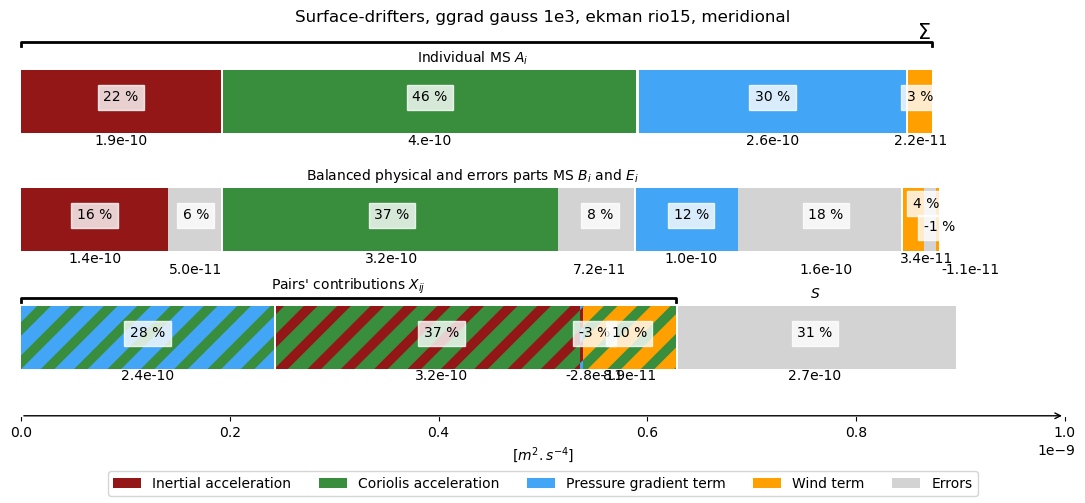

In [35]:
plt.rcParams["axes.edgecolor"] = "w"
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(11,5), frameon=False, )

synthetic_figure(bs,'e', ax, xlim=1e-9) 
fig.legend(ncol=5,loc='lower center')
fig.tight_layout(rect=[0,0.04,1,1])#left, bottom, right, top (default is 0,0,1,1)
fig.suptitle('Surface-drifters, ggrad gauss 1e3, ekman rio15, meridional')
#fig.savefig('images/synth_alg.png',bbox_inches='tight',   dpi=300)

5.502495919198071e-10
<xarray.DataArray ()> Size: 8B
array(5.61634761e-10)
Coordinates:
    id_comb  <U63 252B 'eta_swot250gauss1e3__15era5'


Text(0.5, 0.98, 'Depth-drifters, ggrad gauss 1e3, ekman rio15, zonal')

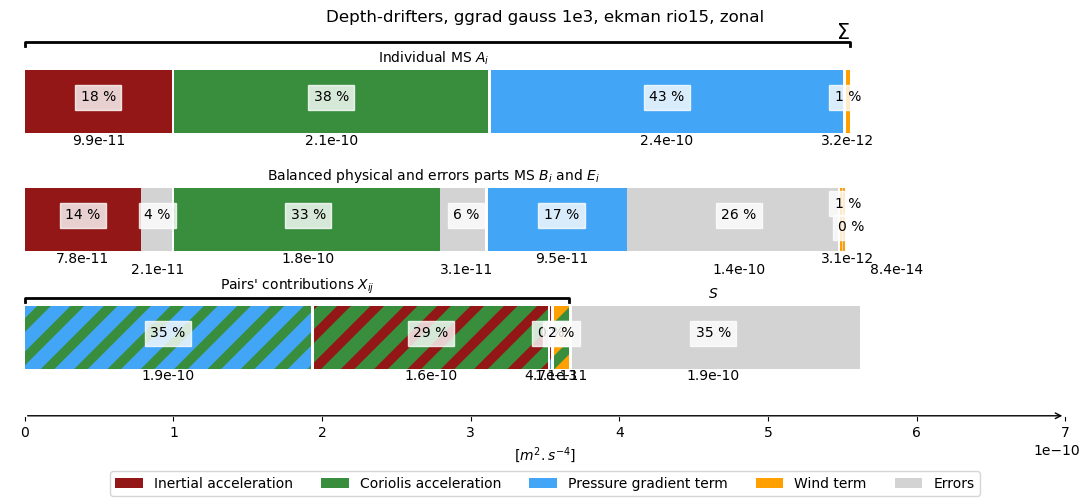

In [34]:
plt.rcParams["axes.edgecolor"] = "w"
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(11,5), frameon=False, )

synthetic_figure(bd,'e', ax, xlim=7e-10) 
fig.legend(ncol=5,loc='lower center')
fig.tight_layout(rect=[0,0.04,1,1])#left, bottom, right, top (default is 0,0,1,1)
fig.suptitle('Depth-drifters, ggrad gauss 1e3, ekman rio15, zonal')
#fig.savefig('images/synth_alg.png',bbox_inches='tight',   dpi=300)

6.34655200868939e-10
<xarray.DataArray ()> Size: 8B
array(6.4182108e-10)
Coordinates:
    id_comb  <U63 252B 'eta_swot250gauss1e3__15era5'


Text(0.5, 0.98, 'Depth-drifters, ggrad gauss 1e3, ekman rio15, meridional')

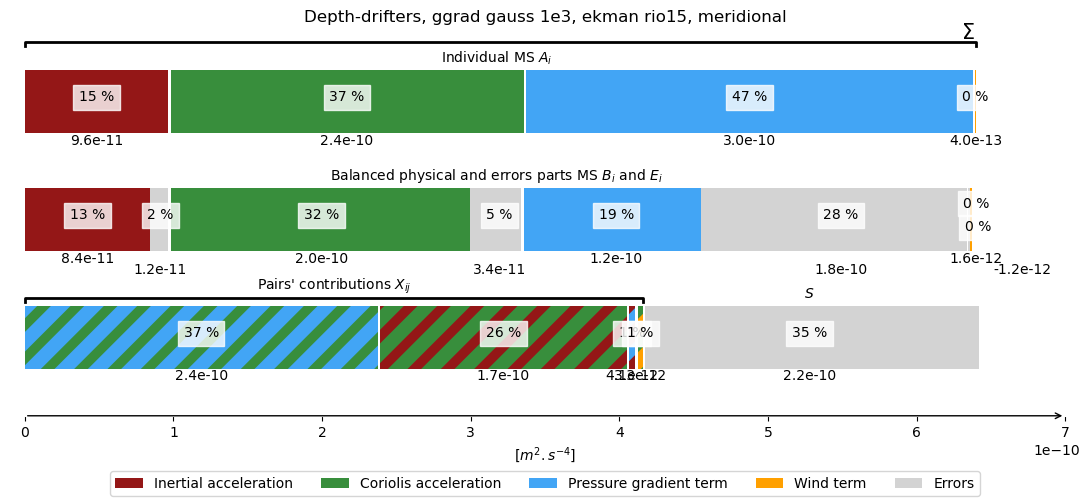

In [33]:
plt.rcParams["axes.edgecolor"] = "w"
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(11,5), frameon=False, )

synthetic_figure(bd,'n', ax, xlim=7e-10) 
fig.legend(ncol=5,loc='lower center')
fig.tight_layout(rect=[0,0.04,1,1])#left, bottom, right, top (default is 0,0,1,1)
fig.suptitle('Depth-drifters, ggrad gauss 1e3, ekman rio15, meridional')
#fig.savefig('images/synth_alg.png',bbox_inches='tight',   dpi=300)

6.047701414633496e-10
<xarray.DataArray ()> Size: 8B
array(6.17326109e-10)
Coordinates:
    id_comb  <U63 252B 'eta_swot250naive__15era5'


Text(0.5, 0.98, 'Depth-drifters, ggrad naive, ekman rio15, zonal')

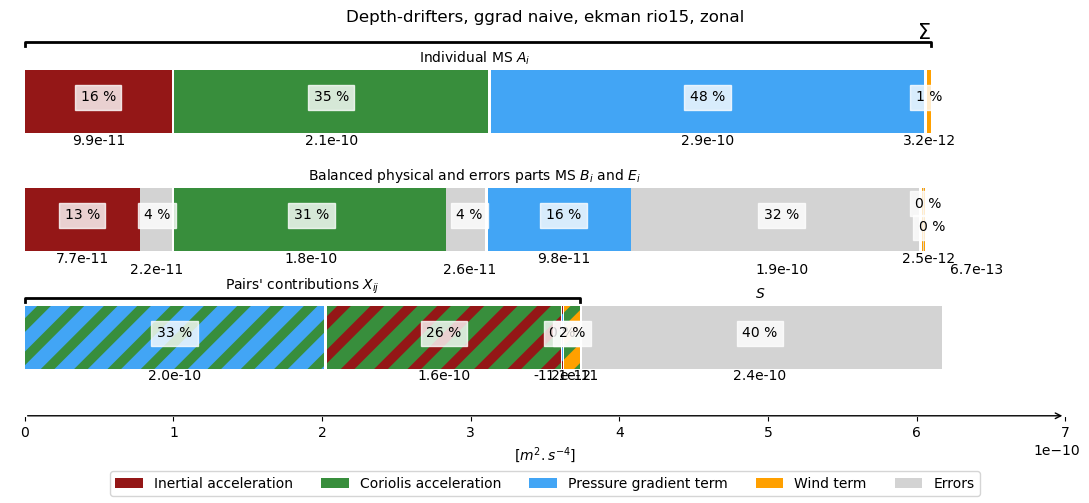

In [32]:
plt.rcParams["axes.edgecolor"] = "w"
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(11,5), frameon=False, )

synthetic_figure(bdn,'e', ax, xlim=7e-10) 
fig.legend(ncol=5,loc='lower center')
fig.tight_layout(rect=[0,0.04,1,1])#left, bottom, right, top (default is 0,0,1,1)
fig.suptitle('Depth-drifters, ggrad naive, ekman rio15, zonal')
#fig.savefig('images/synth_alg.png',bbox_inches='tight',   dpi=300)

6.765292466166386e-10
<xarray.DataArray ()> Size: 8B
array(6.84157467e-10)
Coordinates:
    id_comb  <U63 252B 'eta_swot250naive__15era5'


Text(0.5, 0.98, 'Depth-drifters, ggrad naive, ekman rio15, meridional')

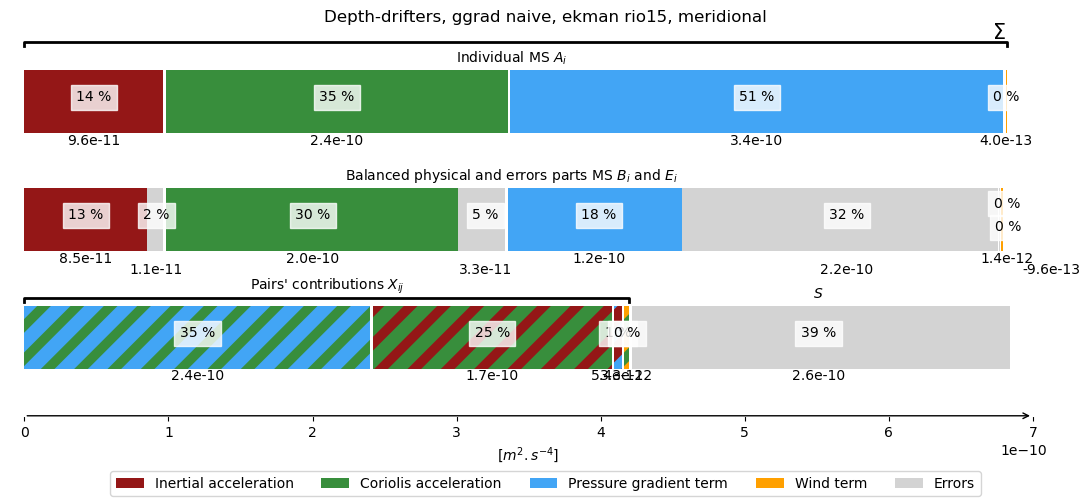

In [31]:
plt.rcParams["axes.edgecolor"] = "w"
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(11,5), frameon=False, )

synthetic_figure(bdn,'n', ax, xlim=7e-10) 
fig.legend(ncol=5,loc='lower center')
fig.tight_layout(rect=[0,0.04,1,1])#left, bottom, right, top (default is 0,0,1,1)
fig.suptitle('Depth-drifters, ggrad naive, ekman rio15, meridional')
#fig.savefig('images/synth_alg.png',bbox_inches='tight',   dpi=300)

9.128749350521258e-10
<xarray.DataArray ()> Size: 8B
array(9.45607111e-10)
Coordinates:
    id_comb  <U63 252B 'eta_swot250naive__0era5'


Text(0.5, 0.98, 'Surface-drifters, ggrad naive, ekman rio15, zonal')

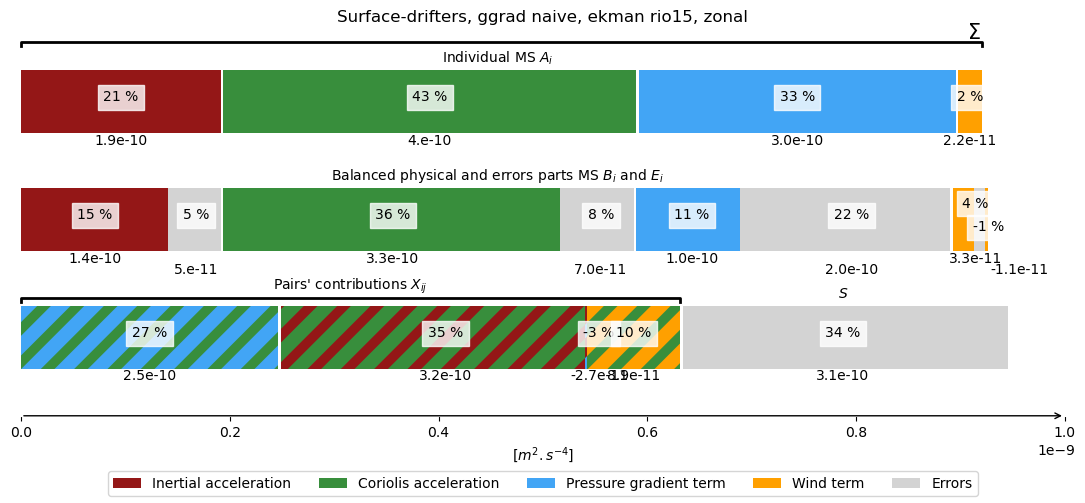

In [30]:
plt.rcParams["axes.edgecolor"] = "w"
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(11,5), frameon=False, )

synthetic_figure(bsn,'e', ax, xlim=1e-9) 
fig.legend(ncol=5,loc='lower center')
fig.tight_layout(rect=[0,0.04,1,1])#left, bottom, right, top (default is 0,0,1,1)
fig.suptitle('Surface-drifters, ggrad naive, ekman rio15, zonal')
#fig.savefig('images/synth_alg.png',bbox_inches='tight',   dpi=300)